FFT on global audio (noise)

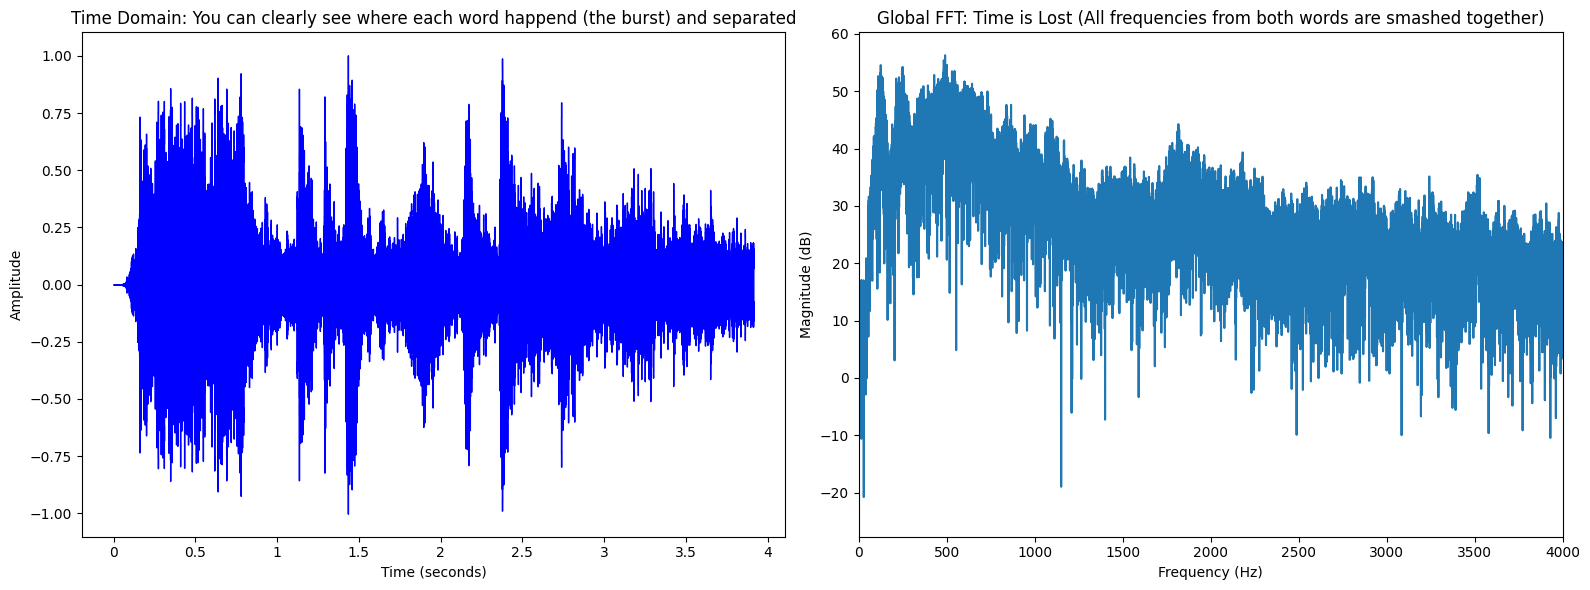

In [7]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# 1. Load a 3-second audio clip containing two distinct words
# Ensure you have a file named 'input.wav' or change the path
y, sr = librosa.load('./data/noise/audio_4.wav')

# 2. Compute the Global FFT
# We take the FFT of the entire 3-second signal at once
fft_spectrum = np.abs(np.fft.rfft(y))
frequencies = np.fft.rfftfreq(len(y), d=1/sr)

# 3. Plotting
plt.figure(figsize=(16, 6))

# Top Plot: Time Domain (Waveform)
plt.subplot(1, 2, 1)
librosa.display.waveshow(y, sr=sr, color='blue')
plt.title("Time Domain: You can clearly see where each word happend (the burst) and separated")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

# Bottom Plot: Global FFT Magnitude Spectrum
plt.subplot(1, 2, 2)
# We convert to decibels (dB) for better visualization of quiet noise
plt.plot(frequencies, librosa.amplitude_to_db(fft_spectrum))
plt.title("Global FFT: Time is Lost (All frequencies from both words are smashed together)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 4000)  # Zoom into the human speech range (0-4kHz)

plt.tight_layout()
plt.show()

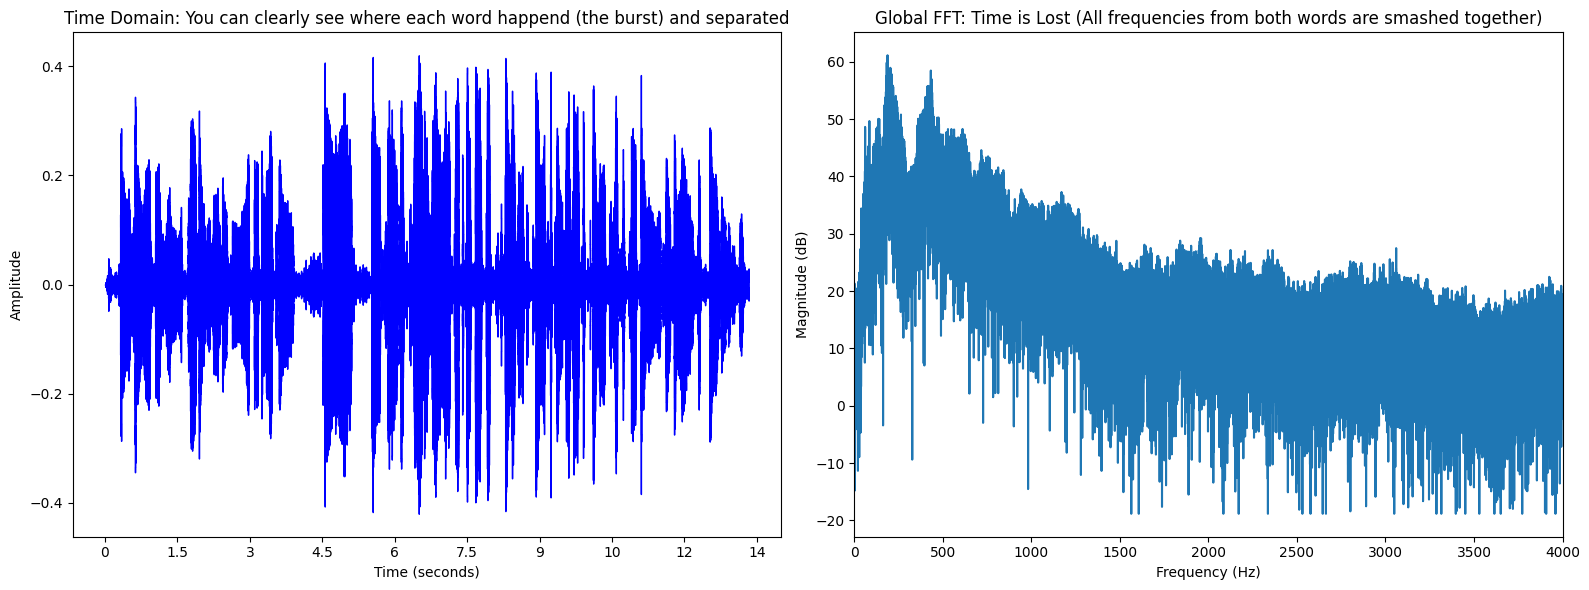

In [8]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# 1. Load a 3-second audio clip containing two distinct words
# Ensure you have a file named 'input.wav' or change the path
y, sr = librosa.load('./data/clean/audio_1.wav')

# 2. Compute the Global FFT
# We take the FFT of the entire 3-second signal at once
fft_spectrum = np.abs(np.fft.rfft(y))
frequencies = np.fft.rfftfreq(len(y), d=1/sr)

# 3. Plotting
plt.figure(figsize=(16, 6))

# Top Plot: Time Domain (Waveform)
plt.subplot(1, 2, 1)
librosa.display.waveshow(y, sr=sr, color='blue')
plt.title("Time Domain: You can clearly see where each word happend (the burst) and separated")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

# Bottom Plot: Global FFT Magnitude Spectrum
plt.subplot(1, 2, 2)
# We convert to decibels (dB) for better visualization of quiet noise
plt.plot(frequencies, librosa.amplitude_to_db(fft_spectrum))
plt.title("Global FFT: Time is Lost (All frequencies from both words are smashed together)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 4000)  # Zoom into the human speech range (0-4kHz)

plt.tight_layout()
plt.show()

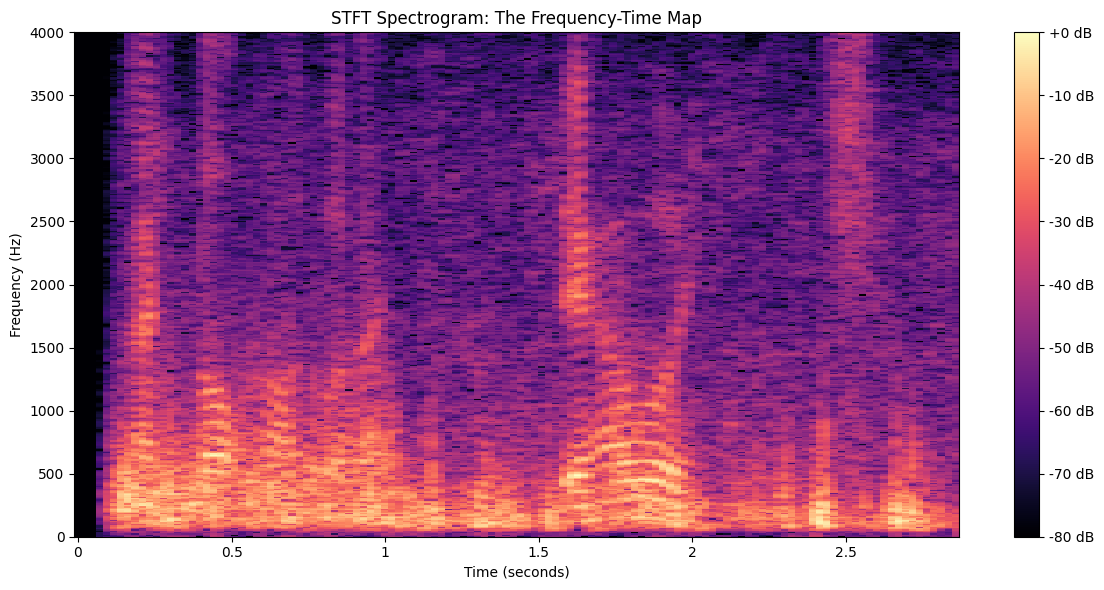

In [11]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# 1. Load the same 3-second audio clip
y, sr = librosa.load('./data/noise/audio_1.wav', duration=3.0)

# 2. Compute the STFT
# n_fft=2048 and hop_length=512 are standard for clear speech visualization
stft = librosa.stft(y, n_fft=2048, hop_length=512)
s_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

# 3. Plotting the Spectrogram
plt.figure(figsize=(12, 6))
librosa.display.specshow(s_db, sr=sr, x_axis='time', y_axis='hz', cmap='magma')

plt.title("STFT Spectrogram: The Frequency-Time Map")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.ylim(0, 4000)  # Focus on the speech range
plt.colorbar(format='%+2.0f dB')

plt.tight_layout()
plt.show()

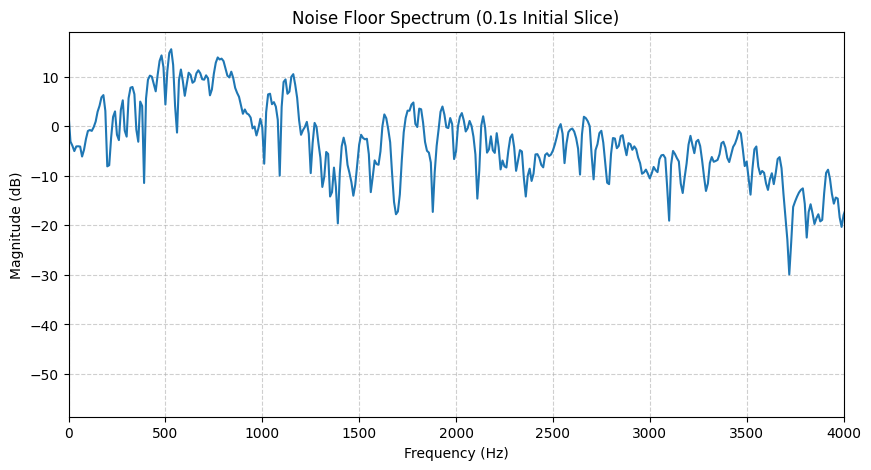

In [13]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

# 1. Load the audio file
y, sr = librosa.load('./data/noise/audio_4.wav', sr=None)

# 2. Extract a 0.1-second slice from the very beginning (noise only)
# duration * sampling_rate = number of samples
noise_sample = y[:int(0.1 * sr)]

# 3. Perform a standard FFT on this slice
# We use rfft for real-valued audio signals
fft_noise = np.abs(np.fft.rfft(noise_sample))
frequencies = np.fft.rfftfreq(len(noise_sample), d=1/sr)

# 4. Plotting the Magnitude Spectrum
plt.figure(figsize=(10, 5))
# Convert magnitude to Decibels (dB) for better visualization of low-level noise
plt.plot(frequencies, librosa.amplitude_to_db(fft_noise))

plt.title("Noise Floor Spectrum (0.1s Initial Slice)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 4000)  # Focus on the speech frequency range
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

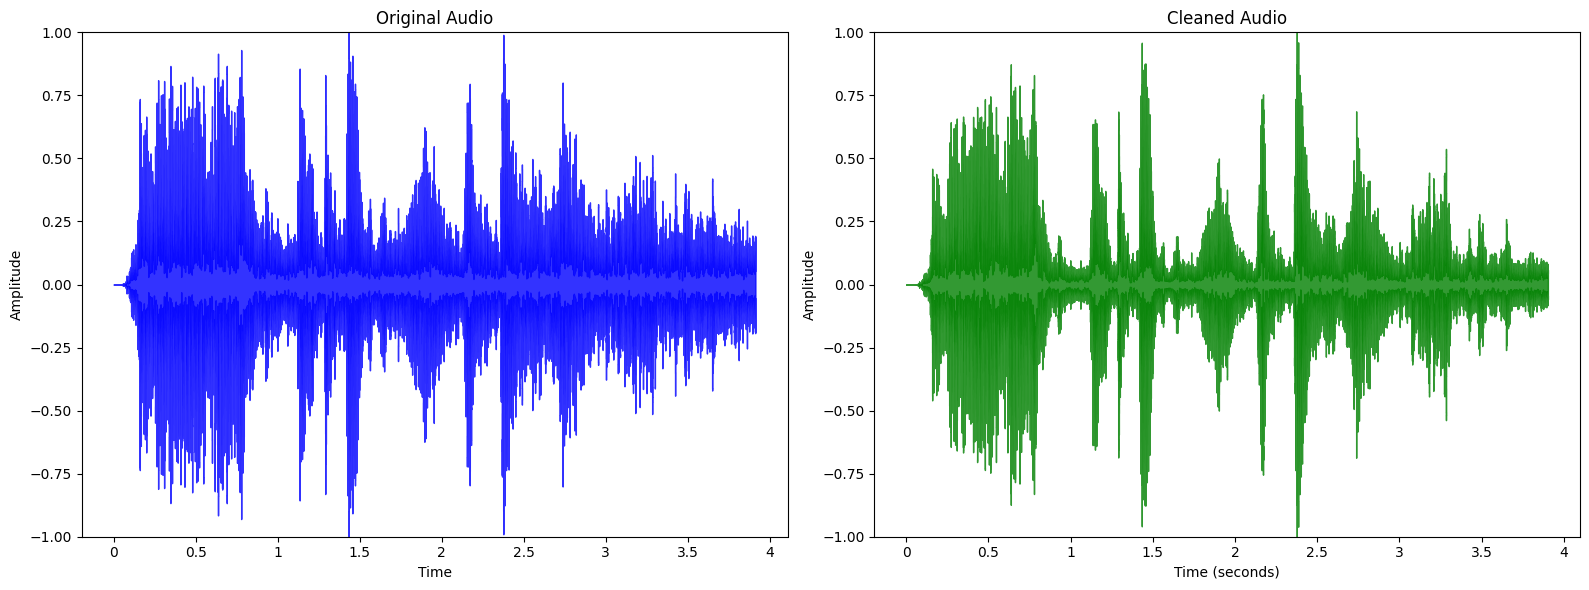

In [4]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# 1. Load your original noisy audio
y_noisy, sr_noisy = librosa.load('./data/noise/audio_4.wav', sr=None)
y_cleaned, sr_cleaned = librosa.load('./output_audio_v4.wav', sr=None)

plt.figure(figsize=(16, 6))

# --- TOP PLOT: Original Noisy Signal ---
plt.subplot(1, 2, 1)
librosa.display.waveshow(y_noisy, sr=sr_noisy, color='blue', alpha=0.8)
plt.title("Original Audio")
plt.ylabel("Amplitude")
plt.ylim(-1, 1) # Keep scales consistent for fair comparison

# --- BOTTOM PLOT: Cleaned Signal (Method 1) ---
plt.subplot(1, 2, 2)
librosa.display.waveshow(y_cleaned, sr=sr_cleaned, color='green', alpha=0.8)
plt.title("Cleaned Audio")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.ylim(-1, 1)

plt.tight_layout()
plt.show()

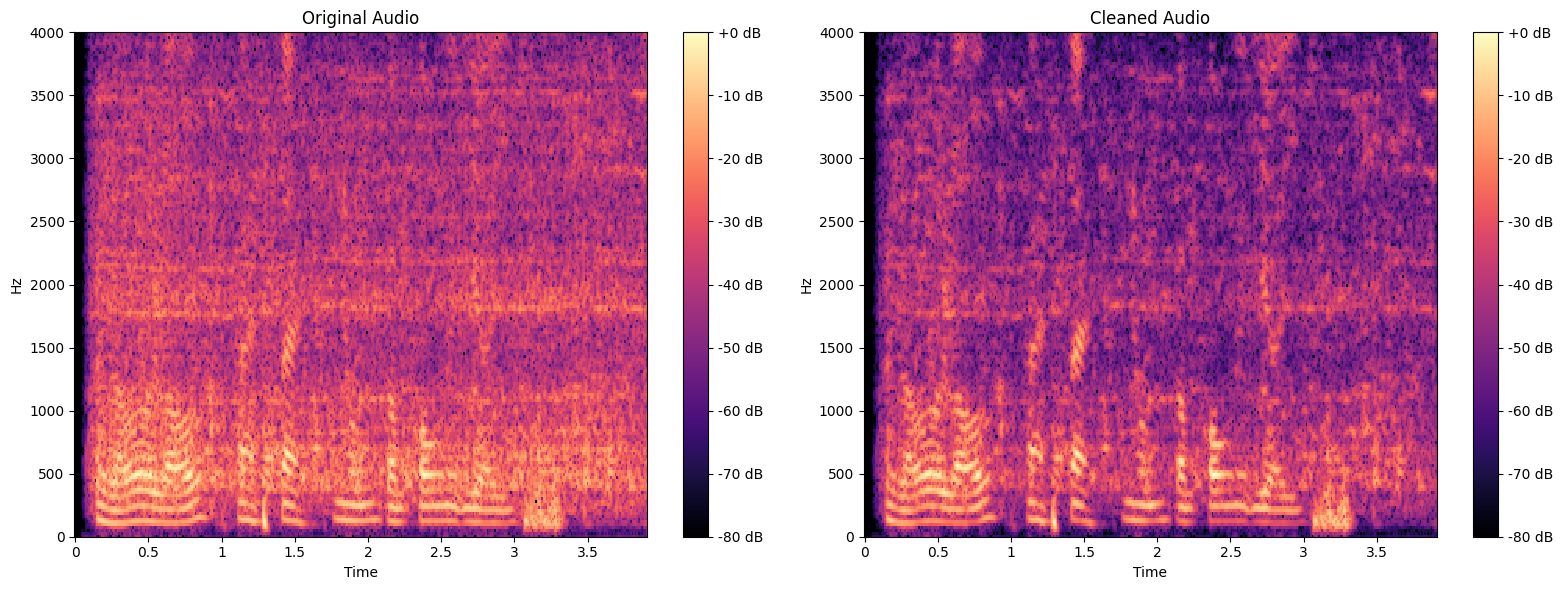

In [6]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# 1. Load Audio Files
# Ensure y_cleaned is the output from your spectral subtraction pipeline
y_noisy, sr_noisy = librosa.load('./data/noise/audio_4.wav', sr=None)
y_cleaned, sr_cleaned = librosa.load('./output_audio_v4.wav', sr=None)

# 2. Compute STFT for both
D_noisy = librosa.stft(y_noisy)
D_cleaned = librosa.stft(y_cleaned)

# 3. Convert to Decibels (dB) for visualization
S_db_noisy = librosa.amplitude_to_db(np.abs(D_noisy), ref=np.max)
S_db_cleaned = librosa.amplitude_to_db(np.abs(D_cleaned), ref=np.max)

# 4. Plotting
plt.figure(figsize=(16, 6))

# Left Plot: Noisy Spectrogram
plt.subplot(1, 2, 1)
librosa.display.specshow(S_db_noisy, sr=sr_noisy, x_axis='time', y_axis='hz', cmap='magma')
plt.title("Original Audio")
plt.colorbar(format='%+2.0f dB')
plt.ylim(0, 4000)

# Right Plot: Cleaned Spectrogram
plt.subplot(1, 2, 2)
librosa.display.specshow(S_db_cleaned, sr=sr_cleaned, x_axis='time', y_axis='hz', cmap='magma')
plt.title("Cleaned Audio")
plt.colorbar(format='%+2.0f dB')
plt.ylim(0, 4000)

plt.tight_layout()
plt.show()